In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
from google.colab import files
uploaded = files.upload()


Saving Sample - Superstore.csv to Sample - Superstore (1).csv


In [13]:
df = pd.read_csv('Sample - Superstore (1).csv', encoding='latin-1')

In [14]:
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

df[['Order Date','Year','Month']].head()

,Order Date,Year,Month
0,2016-11-08,2016,11
1,2016-11-08,2016,11
2,2016-06-12,2016,6
3,2015-10-11,2015,10
4,2015-10-11,2015,10


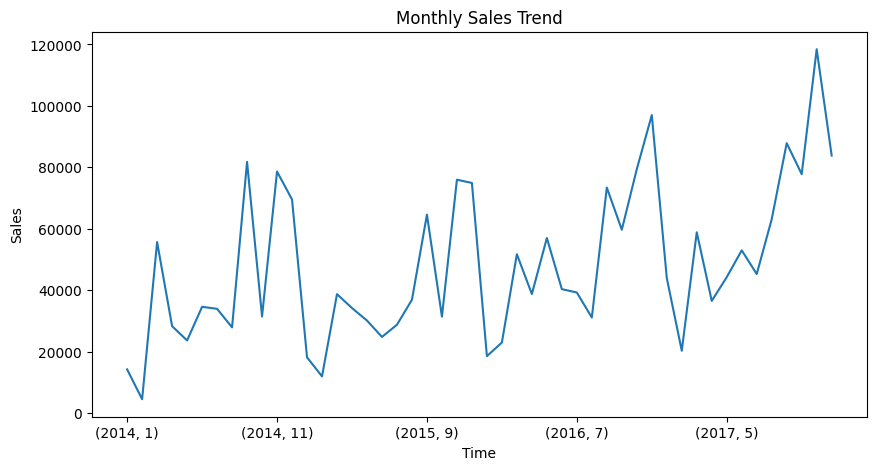

In [16]:
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.show()

                       Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


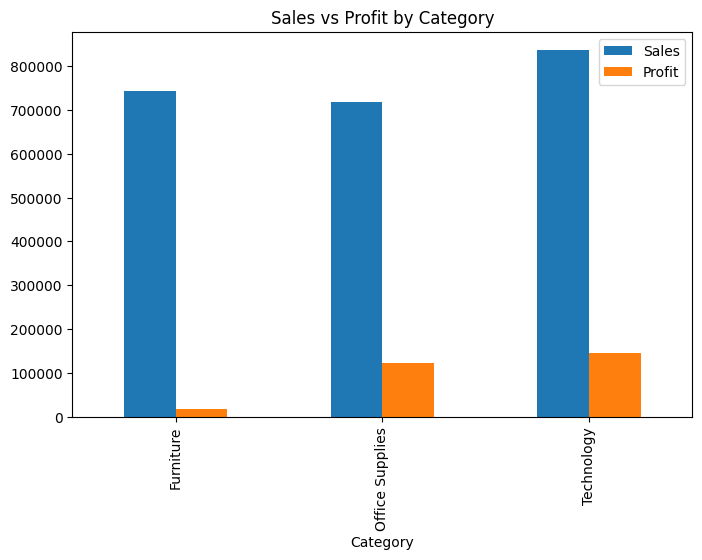

In [17]:
category_analysis = df.groupby('Category')[['Sales','Profit']].sum()

print(category_analysis)

category_analysis.plot(kind='bar', figsize=(8,5))
plt.title("Sales vs Profit by Category")
plt.show()

In [18]:
loss_products = df[df['Profit'] < 0]

loss_products[['Product Name','Sales','Profit']].head()

,Product Name,Sales,Profit
3,Bretford CR4500 Series Slim Rectangular Table,957.5775,-383.0310
14,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,-123.8580
15,Storex DuraTech Recycled Plastic Frosted Binders,2.5440,-3.8160
23,"Global Deluxe Stacking Chair, Gray",71.3720,-1.0196
27,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,-1665.0522


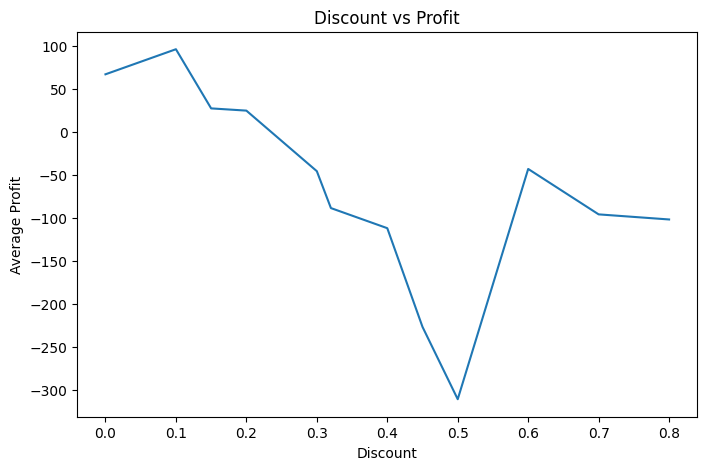

In [19]:
discount_profit = df.groupby('Discount')['Profit'].mean()

discount_profit.plot(figsize=(8,5))
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.show()

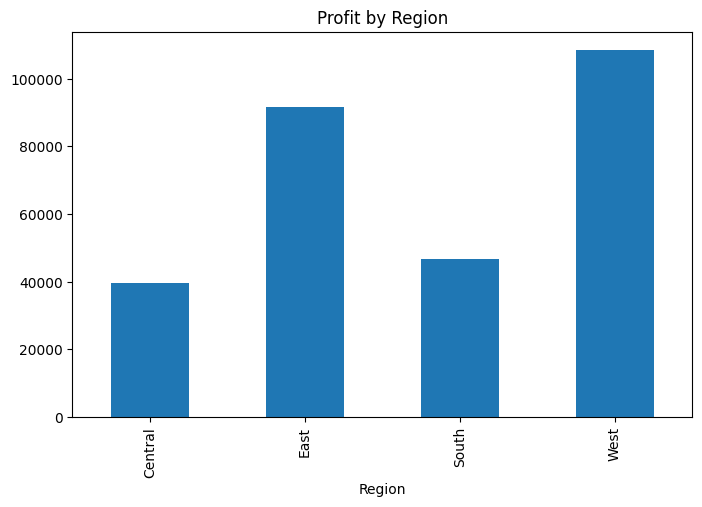

In [20]:
region_profit = df.groupby('Region')['Profit'].sum()

region_profit.plot(kind='bar', figsize=(8,5))
plt.title("Profit by Region")
plt.show()

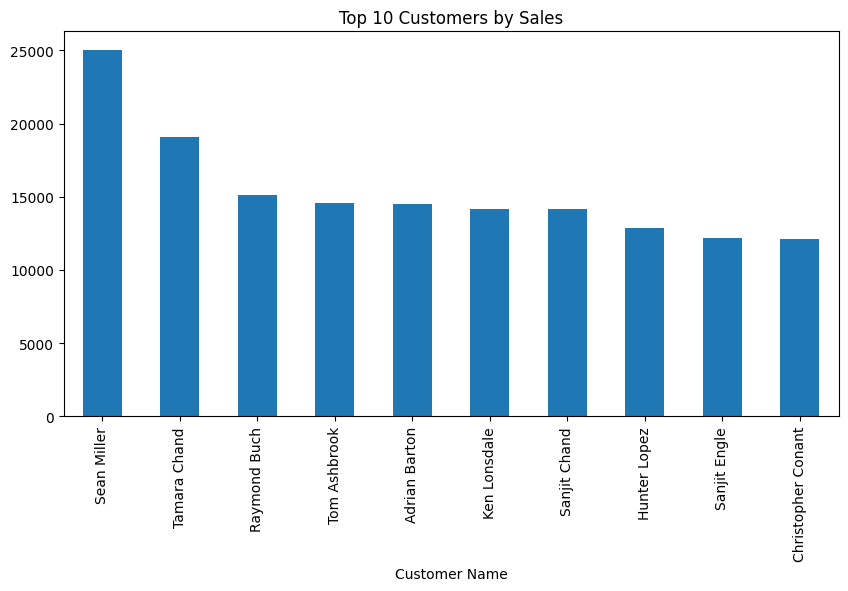

In [21]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Customers by Sales")
plt.show()

In [22]:
print("=== KEY INSIGHTS ===")
print("1. Technology category generates highest revenue.")
print("2. Some products are generating losses.")
print("3. Higher discounts often reduce profit.")
print("4. Certain regions perform better than others.")

=== KEY INSIGHTS ===
1. Technology category generates highest revenue.
2. Some products are generating losses.
3. Higher discounts often reduce profit.
4. Certain regions perform better than others.


In [23]:
print("=== BUSINESS RECOMMENDATIONS ===")
print("- Reduce discounts on loss-making products")
print("- Focus marketing on high-profit categories")
print("- Improve performance in low-profit regions")
print("- Target top customers with loyalty programs")

=== BUSINESS RECOMMENDATIONS ===
- Reduce discounts on loss-making products
- Focus marketing on high-profit categories
- Improve performance in low-profit regions
- Target top customers with loyalty programs
